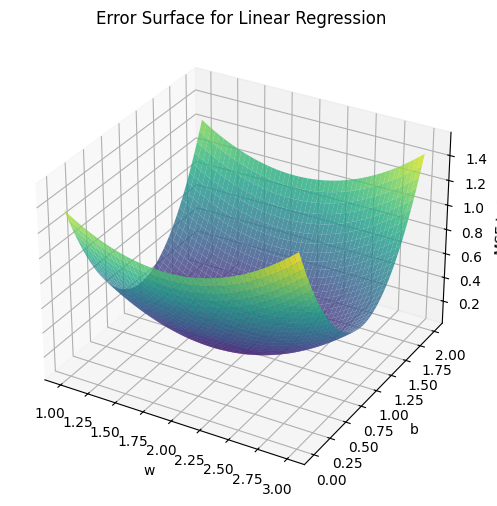

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
# Example: Error surface for linear regression (y = wx + b)
np.random.seed(0)
x = np.linspace(-1, 1, 50)
y_true = 2 * x + 1 + 0.2 * np.random.randn(*x.shape)
# Grid of parameters
w = np.linspace(1, 3, 50)
b = np.linspace(0, 2, 50)
W, B = np.meshgrid(w, b)
loss = np.zeros_like(W)
for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        y_pred = W[i, j] * x + B[i, j]
        loss[i, j] = np.mean((y_true - y_pred)**2)
# Plot error surface
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(W, B, loss, cmap='viridis', alpha=0.8)
ax.set_xlabel('w')
ax.set_ylabel('b')
ax.set_zlabel('MSE Loss')
ax.set_title('Error Surface for Linear Regression')
plt.show()

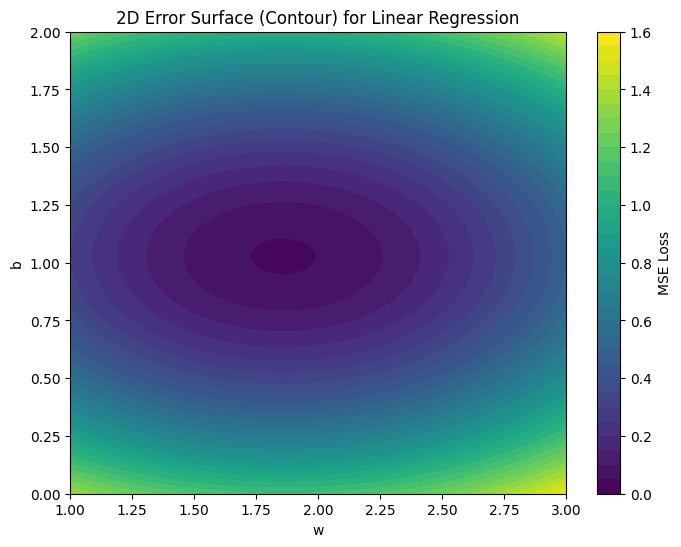

In [2]:
import numpy as np
import matplotlib.pyplot as plt
# Example: 2D error surface (contour) for linear regression
np.random.seed(0)
x = np.linspace(-1, 1, 50)
y_true = 2 * x + 1 + 0.2 * np.random.randn(*x.shape)
w = np.linspace(1, 3, 100)
b = np.linspace(0, 2, 100)
W, B = np.meshgrid(w, b)
loss = np.zeros_like(W)
for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        y_pred = W[i, j] * x + B[i, j]
        loss[i, j] = np.mean((y_true - y_pred)**2)
plt.figure(figsize=(8, 6))
cp = plt.contourf(W, B, loss, levels=30, cmap='viridis')
plt.colorbar(cp, label='MSE Loss')
plt.xlabel('w')
plt.ylabel('b')
plt.title('2D Error Surface (Contour) for Linear Regression')
plt.show()

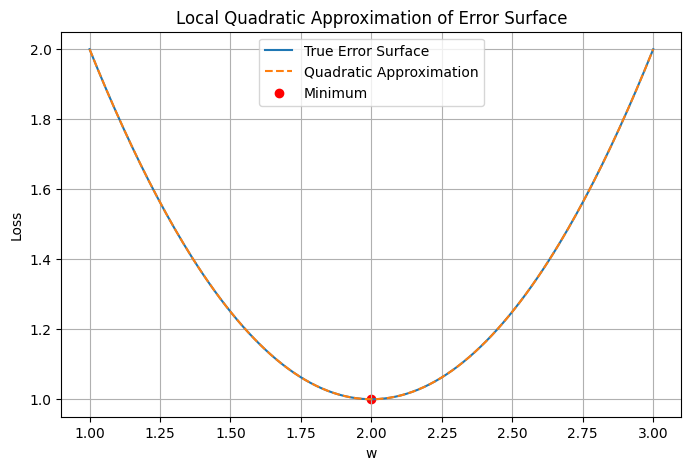

In [3]:
import numpy as np
import matplotlib.pyplot as plt
# Example: Local quadratic approximation of error surface near minimum
def error_func(w):
    return (w - 2)**2 + 1
# True error surface
w = np.linspace(1, 3, 200)
loss = error_func(w)
# Find minimum
w_min = 2
loss_min = error_func(w_min)
# Quadratic approximation (Taylor expansion at w_min)
approx = loss_min + 0.5 * 2 * (w - w_min)**2 # second derivative is 2
# Plot
plt.figure(figsize=(8, 5))
plt.plot(w, loss, label='True Error Surface')
plt.plot(w, approx, '--', label='Quadratic Approximation')
plt.scatter([w_min], [loss_min], color='red', label='Minimum')
plt.title('Local Quadratic Approximation of Error Surface')
plt.xlabel('w')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

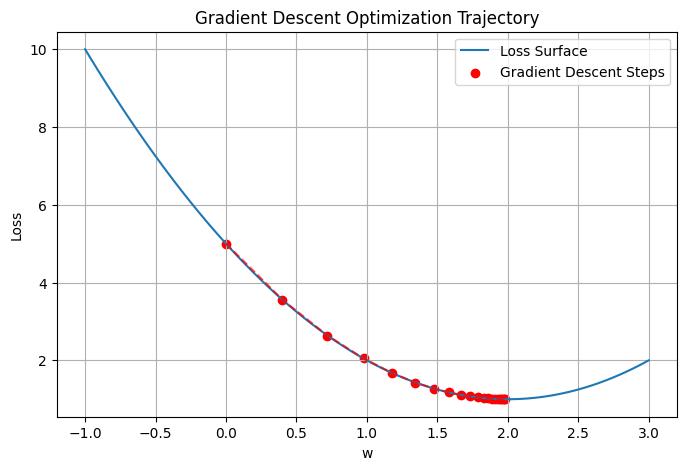

In [4]:
# Gradient Descent Optimization Example
import numpy as np
import matplotlib.pyplot as plt

# Define a simple quadratic loss function: L(w) = (w - 2)**2 + 1
def loss(w):
    return (w - 2)**2 + 1

# Gradient of the loss function
def grad(w):
    return 2 * (w - 2)

# Gradient descent parameters
w = 0.0  # initial guess
lr = 0.1  # learning rate
n_steps = 20

ws = [w]
losses = [loss(w)]

for step in range(n_steps):
    w = w - lr * grad(w)
    ws.append(w)
    losses.append(loss(w))

# Plot optimization trajectory
w_grid = np.linspace(-1, 3, 100)
plt.figure(figsize=(8, 5))
plt.plot(w_grid, loss(w_grid), label='Loss Surface')
plt.scatter(ws, losses, color='red', label='Gradient Descent Steps')
plt.plot(ws, losses, '--', color='red', alpha=0.7)
plt.xlabel('w')
plt.ylabel('Loss')
plt.title('Gradient Descent Optimization Trajectory')
plt.legend()
plt.grid(True)
plt.show()

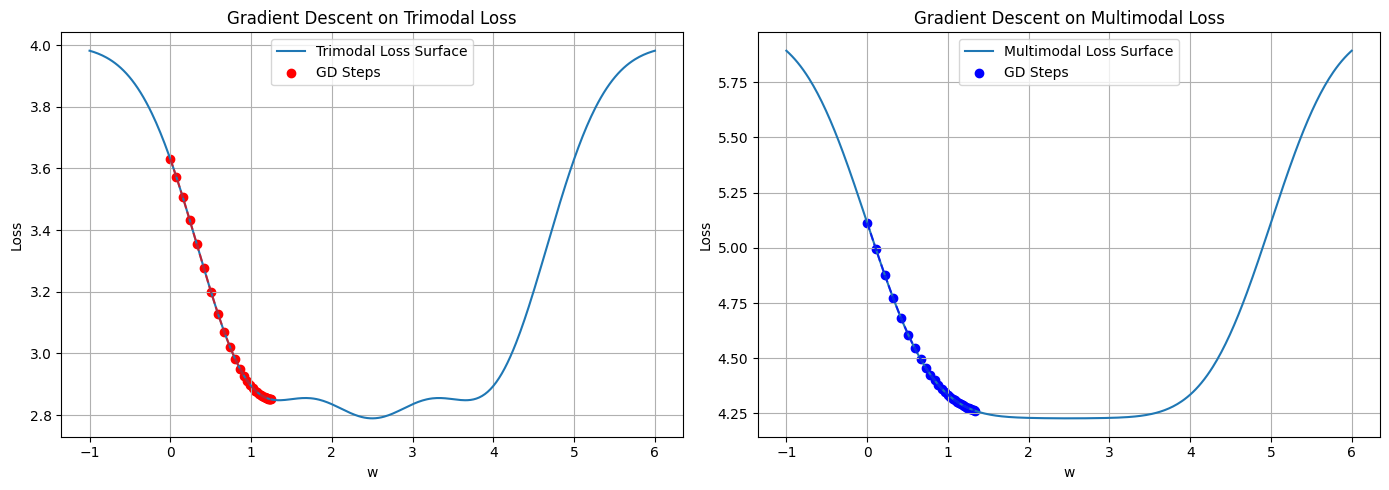

In [5]:
# Gradient Descent on Trimodal and Multimodal Loss Functions
import numpy as np
import matplotlib.pyplot as plt

# Trimodal loss function: sum of three Gaussians (negative peaks)
def trimodal_loss(w):
    return (np.exp(-(w-1)**2) + np.exp(-(w-2.5)**2) + np.exp(-(w-4)**2)) * -1 + 4

# Multimodal loss function: sum of five Gaussians (negative peaks)
def multimodal_loss(w):
    centers = [0.5, 1.5, 2.5, 3.5, 4.5]
    return sum(np.exp(-(w-c)**2) for c in centers) * -1 + 6

# Gradient (numerical)
def numerical_grad(f, w):
    eps = 1e-5
    return (f(w + eps) - f(w - eps)) / (2 * eps)

def gradient_descent(f, grad_f, w0, lr, n_steps):
    ws = [w0]
    losses = [f(w0)]
    w = w0
    for _ in range(n_steps):
        g = grad_f(f, w)
        w = w - lr * g
        ws.append(w)
        losses.append(f(w))
    return np.array(ws), np.array(losses)

# Run gradient descent on trimodal loss
w0 = 0.0
lr = 0.1
n_steps = 30
ws_tri, losses_tri = gradient_descent(trimodal_loss, numerical_grad, w0, lr, n_steps)

# Run gradient descent on multimodal loss
ws_multi, losses_multi = gradient_descent(multimodal_loss, numerical_grad, w0, lr, n_steps)

# Plotting
w_grid = np.linspace(-1, 6, 400)
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(w_grid, trimodal_loss(w_grid), label='Trimodal Loss Surface')
plt.scatter(ws_tri, losses_tri, color='red', label='GD Steps')
plt.plot(ws_tri, losses_tri, '--', color='red', alpha=0.7)
plt.title('Gradient Descent on Trimodal Loss')
plt.xlabel('w')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(w_grid, multimodal_loss(w_grid), label='Multimodal Loss Surface')
plt.scatter(ws_multi, losses_multi, color='blue', label='GD Steps')
plt.plot(ws_multi, losses_multi, '--', color='blue', alpha=0.7)
plt.title('Gradient Descent on Multimodal Loss')
plt.xlabel('w')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

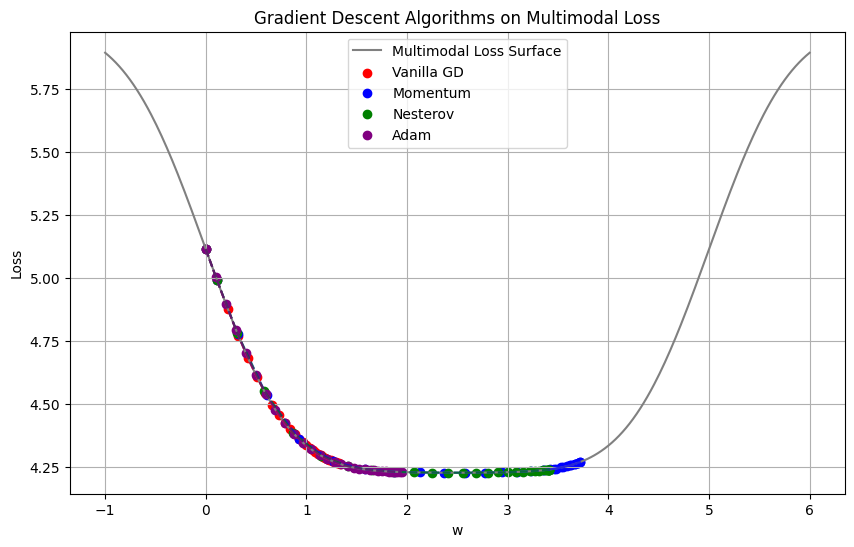

In [6]:
# Comparison of Gradient Descent Algorithms on a Multimodal Loss Function
import numpy as np
import matplotlib.pyplot as plt

# Multimodal loss function: sum of five Gaussians (negative peaks)
def multimodal_loss(w):
    centers = [0.5, 1.5, 2.5, 3.5, 4.5]
    return sum(np.exp(-(w-c)**2) for c in centers) * -1 + 6

def numerical_grad(f, w):
    eps = 1e-5
    return (f(w + eps) - f(w - eps)) / (2 * eps)

# Vanilla Gradient Descent
def gd_vanilla(f, grad_f, w0, lr, n_steps):
    ws = [w0]
    w = w0
    for _ in range(n_steps):
        g = grad_f(f, w)
        w = w - lr * g
        ws.append(w)
    return np.array(ws)

# Gradient Descent with Momentum
def gd_momentum(f, grad_f, w0, lr, n_steps, beta=0.9):
    ws = [w0]
    w = w0
    v = 0
    for _ in range(n_steps):
        g = grad_f(f, w)
        v = beta * v + lr * g
        w = w - v
        ws.append(w)
    return np.array(ws)

# Nesterov Accelerated Gradient
def gd_nesterov(f, grad_f, w0, lr, n_steps, beta=0.9):
    ws = [w0]
    w = w0
    v = 0
    for _ in range(n_steps):
        g = grad_f(f, w - beta * v)
        v = beta * v + lr * g
        w = w - v
        ws.append(w)
    return np.array(ws)

# Adam Optimizer
def gd_adam(f, grad_f, w0, lr, n_steps, beta1=0.9, beta2=0.999, eps=1e-8):
    ws = [w0]
    w = w0
    m = 0
    v = 0
    for t in range(1, n_steps+1):
        g = grad_f(f, w)
        m = beta1 * m + (1 - beta1) * g
        v = beta2 * v + (1 - beta2) * (g**2)
        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)
        w = w - lr * m_hat / (np.sqrt(v_hat) + eps)
        ws.append(w)
    return np.array(ws)

# Run all optimizers
w0 = 0.0
lr = 0.1
n_steps = 30

ws_vanilla = gd_vanilla(multimodal_loss, numerical_grad, w0, lr, n_steps)
ws_momentum = gd_momentum(multimodal_loss, numerical_grad, w0, lr, n_steps)
ws_nesterov = gd_nesterov(multimodal_loss, numerical_grad, w0, lr, n_steps)
ws_adam = gd_adam(multimodal_loss, numerical_grad, w0, lr, n_steps)

# Plot trajectories
w_grid = np.linspace(-1, 6, 400)
plt.figure(figsize=(10, 6))
plt.plot(w_grid, multimodal_loss(w_grid), label='Multimodal Loss Surface', color='gray')
plt.scatter(ws_vanilla, multimodal_loss(ws_vanilla), label='Vanilla GD', color='red')
plt.plot(ws_vanilla, multimodal_loss(ws_vanilla), '--', color='red', alpha=0.7)
plt.scatter(ws_momentum, multimodal_loss(ws_momentum), label='Momentum', color='blue')
plt.plot(ws_momentum, multimodal_loss(ws_momentum), '--', color='blue', alpha=0.7)
plt.scatter(ws_nesterov, multimodal_loss(ws_nesterov), label='Nesterov', color='green')
plt.plot(ws_nesterov, multimodal_loss(ws_nesterov), '--', color='green', alpha=0.7)
plt.scatter(ws_adam, multimodal_loss(ws_adam), label='Adam', color='purple')
plt.plot(ws_adam, multimodal_loss(ws_adam), '--', color='purple', alpha=0.7)
plt.title('Gradient Descent Algorithms on Multimodal Loss')
plt.xlabel('w')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

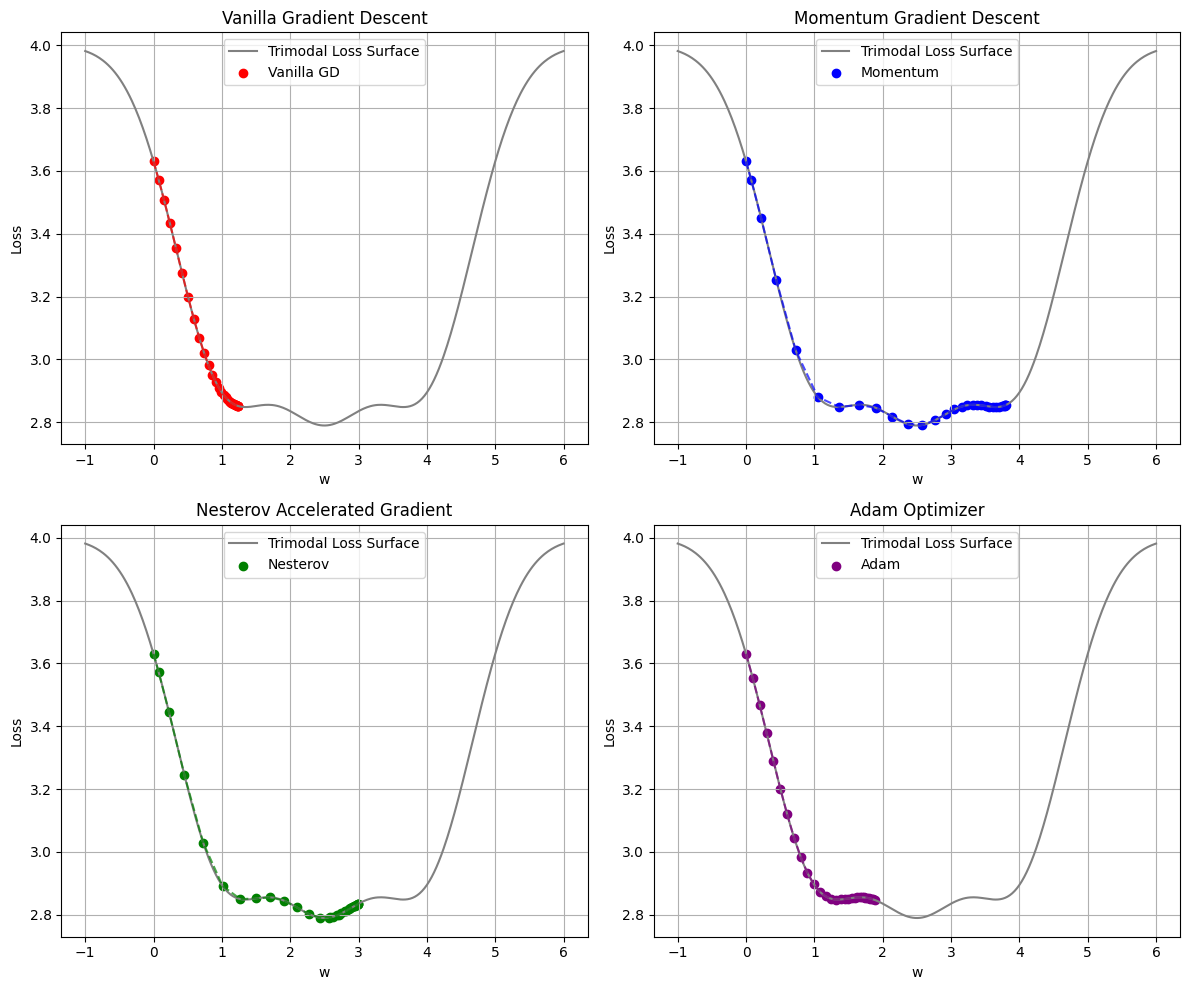

In [7]:
# Individual Gradient Descent Algorithm Plots on Trimodal Loss Function
import numpy as np
import matplotlib.pyplot as plt

# Trimodal loss function: sum of three Gaussians (negative peaks)
def trimodal_loss(w):
    return (np.exp(-(w-1)**2) + np.exp(-(w-2.5)**2) + np.exp(-(w-4)**2)) * -1 + 4

def numerical_grad(f, w):
    eps = 1e-5
    return (f(w + eps) - f(w - eps)) / (2 * eps)

def gd_vanilla(f, grad_f, w0, lr, n_steps):
    ws = [w0]
    w = w0
    for _ in range(n_steps):
        g = grad_f(f, w)
        w = w - lr * g
        ws.append(w)
    return np.array(ws)

def gd_momentum(f, grad_f, w0, lr, n_steps, beta=0.9):
    ws = [w0]
    w = w0
    v = 0
    for _ in range(n_steps):
        g = grad_f(f, w)
        v = beta * v + lr * g
        w = w - v
        ws.append(w)
    return np.array(ws)

def gd_nesterov(f, grad_f, w0, lr, n_steps, beta=0.9):
    ws = [w0]
    w = w0
    v = 0
    for _ in range(n_steps):
        g = grad_f(f, w - beta * v)
        v = beta * v + lr * g
        w = w - v
        ws.append(w)
    return np.array(ws)

def gd_adam(f, grad_f, w0, lr, n_steps, beta1=0.9, beta2=0.999, eps=1e-8):
    ws = [w0]
    w = w0
    m = 0
    v = 0
    for t in range(1, n_steps+1):
        g = grad_f(f, w)
        m = beta1 * m + (1 - beta1) * g
        v = beta2 * v + (1 - beta2) * (g**2)
        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)
        w = w - lr * m_hat / (np.sqrt(v_hat) + eps)
        ws.append(w)
    return np.array(ws)

# Run all optimizers on trimodal loss
w0 = 0.0
lr = 0.1
n_steps = 30

ws_vanilla = gd_vanilla(trimodal_loss, numerical_grad, w0, lr, n_steps)
ws_momentum = gd_momentum(trimodal_loss, numerical_grad, w0, lr, n_steps)
ws_nesterov = gd_nesterov(trimodal_loss, numerical_grad, w0, lr, n_steps)
ws_adam = gd_adam(trimodal_loss, numerical_grad, w0, lr, n_steps)

w_grid = np.linspace(-1, 6, 400)

# Individual plots
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
plt.plot(w_grid, trimodal_loss(w_grid), label='Trimodal Loss Surface', color='gray')
plt.scatter(ws_vanilla, trimodal_loss(ws_vanilla), label='Vanilla GD', color='red')
plt.plot(ws_vanilla, trimodal_loss(ws_vanilla), '--', color='red', alpha=0.7)
plt.title('Vanilla Gradient Descent')
plt.xlabel('w')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(w_grid, trimodal_loss(w_grid), label='Trimodal Loss Surface', color='gray')
plt.scatter(ws_momentum, trimodal_loss(ws_momentum), label='Momentum', color='blue')
plt.plot(ws_momentum, trimodal_loss(ws_momentum), '--', color='blue', alpha=0.7)
plt.title('Momentum Gradient Descent')
plt.xlabel('w')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(w_grid, trimodal_loss(w_grid), label='Trimodal Loss Surface', color='gray')
plt.scatter(ws_nesterov, trimodal_loss(ws_nesterov), label='Nesterov', color='green')
plt.plot(ws_nesterov, trimodal_loss(ws_nesterov), '--', color='green', alpha=0.7)
plt.title('Nesterov Accelerated Gradient')
plt.xlabel('w')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(w_grid, trimodal_loss(w_grid), label='Trimodal Loss Surface', color='gray')
plt.scatter(ws_adam, trimodal_loss(ws_adam), label='Adam', color='purple')
plt.plot(ws_adam, trimodal_loss(ws_adam), '--', color='purple', alpha=0.7)
plt.title('Adam Optimizer')
plt.xlabel('w')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Gradient Descent Algorithms: Explanations
**Vanilla Gradient Descent:**
- Updates parameters in the direction of the negative gradient of the loss function.
- Simple and widely used, but can be slow and get stuck in local minima for complex surfaces.

**Momentum Gradient Descent:**
- Adds a velocity term to the update, accumulating past gradients to accelerate convergence and help escape shallow local minima.
- The update is a combination of the current gradient and previous velocity.

**Nesterov Accelerated Gradient (NAG):**
- Similar to momentum, but computes the gradient at the lookahead position (current parameters minus momentum).
- Provides a more accurate update direction and can converge faster than standard momentum.

**Adam Optimizer:**
- Combines momentum (first moment) and RMSProp (second moment) ideas.
- Maintains running averages of both the gradients and their squares, adapting the learning rate for each parameter.
- Works well for many deep learning problems and is robust to noisy gradients.

**AdamW Optimizer:**
- Variant of Adam that decouples weight decay (L2 regularization) from the gradient update.
- Helps improve generalization and training stability, especially in deep neural networks.
- Weight decay is applied directly to the parameters, not to the gradients.


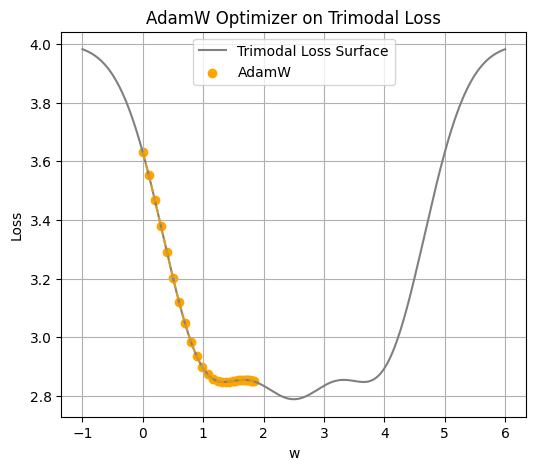

In [8]:
# AdamW Optimizer on Trimodal Loss Function
import numpy as np
import matplotlib.pyplot as plt

def trimodal_loss(w):
    return (np.exp(-(w-1)**2) + np.exp(-(w-2.5)**2) + np.exp(-(w-4)**2)) * -1 + 4

def numerical_grad(f, w):
    eps = 1e-5
    return (f(w + eps) - f(w - eps)) / (2 * eps)

def gd_adamw(f, grad_f, w0, lr, n_steps, beta1=0.9, beta2=0.999, eps=1e-8, weight_decay=0.01):
    ws = [w0]
    w = w0
    m = 0
    v = 0
    for t in range(1, n_steps+1):
        g = grad_f(f, w)
        m = beta1 * m + (1 - beta1) * g
        v = beta2 * v + (1 - beta2) * (g**2)
        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)
        w = w - lr * m_hat / (np.sqrt(v_hat) + eps)
        w = w - lr * weight_decay * w  # decoupled weight decay
        ws.append(w)
    return np.array(ws)

# Run AdamW optimizer
w0 = 0.0
lr = 0.1
n_steps = 30
ws_adamw = gd_adamw(trimodal_loss, numerical_grad, w0, lr, n_steps)

w_grid = np.linspace(-1, 6, 400)
plt.figure(figsize=(6, 5))
plt.plot(w_grid, trimodal_loss(w_grid), label='Trimodal Loss Surface', color='gray')
plt.scatter(ws_adamw, trimodal_loss(ws_adamw), label='AdamW', color='orange')
plt.plot(ws_adamw, trimodal_loss(ws_adamw), '--', color='orange', alpha=0.7)
plt.title('AdamW Optimizer on Trimodal Loss')
plt.xlabel('w')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

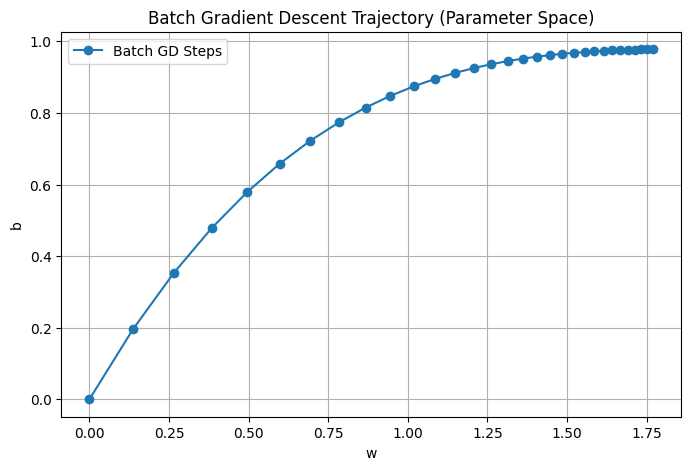

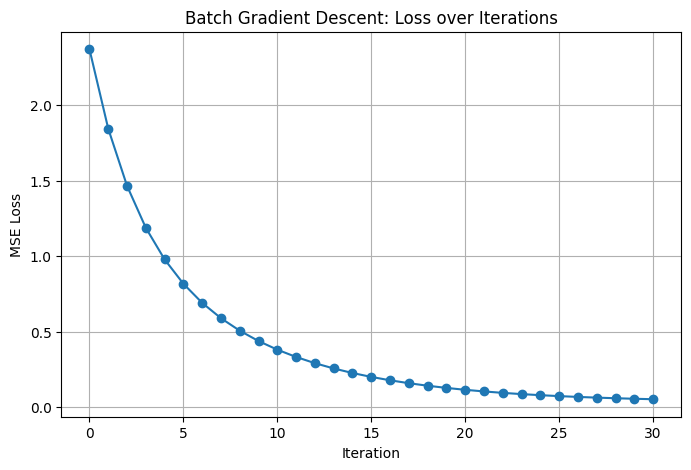

In [9]:
# Batch Gradient Descent Example
import numpy as np
import matplotlib.pyplot as plt

# Synthetic dataset: y = 2x + 1 + noise
np.random.seed(42)
x = np.linspace(-1, 1, 100)
y_true = 2 * x + 1 + 0.2 * np.random.randn(*x.shape)

# Loss function: MSE for linear regression
def mse_loss(w, b, x, y):
    y_pred = w * x + b
    return np.mean((y - y_pred)**2)

# Gradients of MSE loss
def grad_mse(w, b, x, y):
    y_pred = w * x + b
    grad_w = -2 * np.mean((y - y_pred) * x)
    grad_b = -2 * np.mean(y - y_pred)
    return grad_w, grad_b

# Batch Gradient Descent
w, b = 0.0, 0.0
lr = 0.1
n_steps = 30
ws, bs, losses = [w], [b], [mse_loss(w, b, x, y_true)]

for step in range(n_steps):
    grad_w, grad_b = grad_mse(w, b, x, y_true)
    w = w - lr * grad_w
    b = b - lr * grad_b
    ws.append(w)
    bs.append(b)
    losses.append(mse_loss(w, b, x, y_true))

# Plot optimization trajectory in parameter space
plt.figure(figsize=(8, 5))
plt.plot(ws, bs, marker='o', label='Batch GD Steps')
plt.xlabel('w')
plt.ylabel('b')
plt.title('Batch Gradient Descent Trajectory (Parameter Space)')
plt.grid(True)
plt.legend()
plt.show()

# Plot loss over iterations
plt.figure(figsize=(8, 5))
plt.plot(losses, marker='o')
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.title('Batch Gradient Descent: Loss over Iterations')
plt.grid(True)
plt.show()

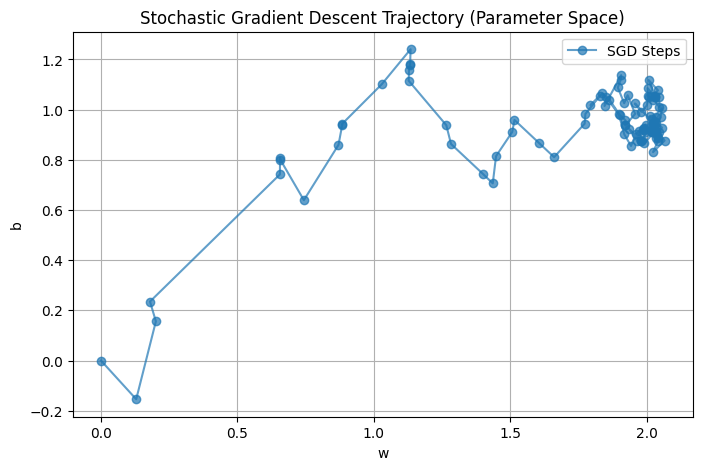

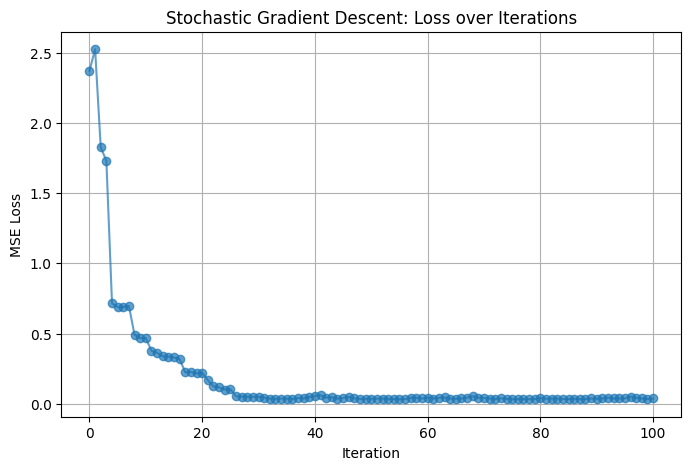

In [10]:
# Stochastic Gradient Descent (SGD) Example
import numpy as np
import matplotlib.pyplot as plt

# Synthetic dataset: y = 2x + 1 + noise
np.random.seed(42)
x = np.linspace(-1, 1, 100)
y_true = 2 * x + 1 + 0.2 * np.random.randn(*x.shape)

# Loss function: MSE for linear regression
def mse_loss(w, b, x, y):
    y_pred = w * x + b
    return np.mean((y - y_pred)**2)

# Gradients of MSE loss for a single sample
def grad_mse_single(w, b, x_i, y_i):
    y_pred = w * x_i + b
    grad_w = -2 * (y_i - y_pred) * x_i
    grad_b = -2 * (y_i - y_pred)
    return grad_w, grad_b

# Stochastic Gradient Descent
w, b = 0.0, 0.0
lr = 0.1
n_steps = 100
ws, bs, losses = [w], [b], [mse_loss(w, b, x, y_true)]

for step in range(n_steps):
    idx = np.random.randint(0, len(x))
    grad_w, grad_b = grad_mse_single(w, b, x[idx], y_true[idx])
    w = w - lr * grad_w
    b = b - lr * grad_b
    ws.append(w)
    bs.append(b)
    losses.append(mse_loss(w, b, x, y_true))

# Plot optimization trajectory in parameter space
plt.figure(figsize=(8, 5))
plt.plot(ws, bs, marker='o', label='SGD Steps', alpha=0.7)
plt.xlabel('w')
plt.ylabel('b')
plt.title('Stochastic Gradient Descent Trajectory (Parameter Space)')
plt.grid(True)
plt.legend()
plt.show()

# Plot loss over iterations
plt.figure(figsize=(8, 5))
plt.plot(losses, marker='o', alpha=0.7)
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.title('Stochastic Gradient Descent: Loss over Iterations')
plt.grid(True)
plt.show()

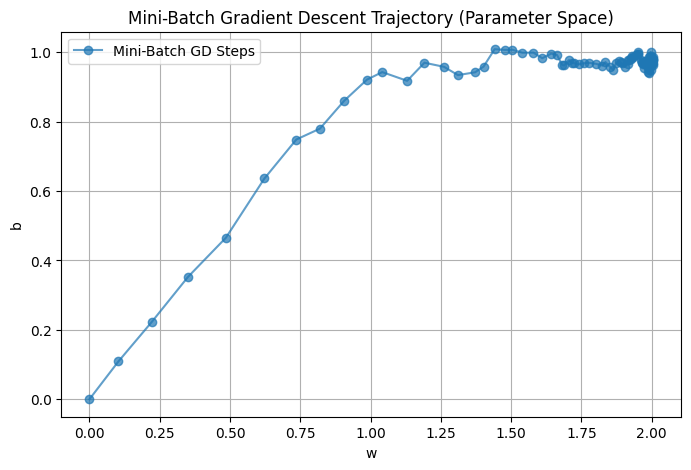

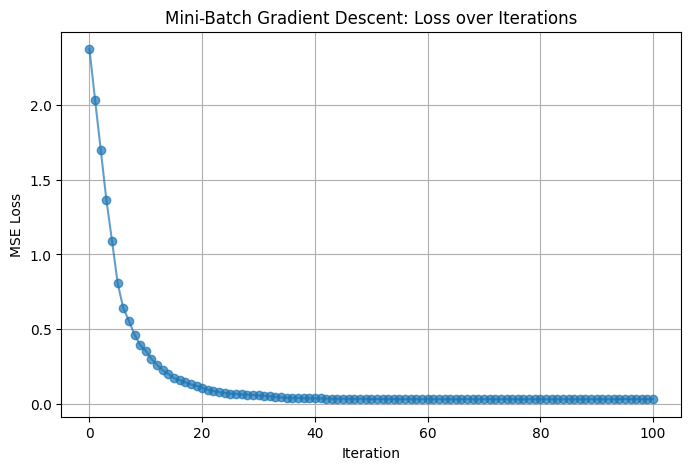

In [11]:
# Mini-Batch Gradient Descent Example
import numpy as np
import matplotlib.pyplot as plt

# Synthetic dataset: y = 2x + 1 + noise
np.random.seed(42)
x = np.linspace(-1, 1, 100)
y_true = 2 * x + 1 + 0.2 * np.random.randn(*x.shape)

# Loss function: MSE for linear regression
def mse_loss(w, b, x, y):
    y_pred = w * x + b
    return np.mean((y - y_pred)**2)

# Gradients of MSE loss for a batch
def grad_mse_batch(w, b, x_batch, y_batch):
    y_pred = w * x_batch + b
    grad_w = -2 * np.mean((y_batch - y_pred) * x_batch)
    grad_b = -2 * np.mean(y_batch - y_pred)
    return grad_w, grad_b

# Mini-Batch Gradient Descent
w, b = 0.0, 0.0
lr = 0.1
n_steps = 100
batch_size = 16
ws, bs, losses = [w], [b], [mse_loss(w, b, x, y_true)]

for step in range(n_steps):
    idx = np.random.choice(len(x), batch_size, replace=False)
    x_batch = x[idx]
    y_batch = y_true[idx]
    grad_w, grad_b = grad_mse_batch(w, b, x_batch, y_batch)
    w = w - lr * grad_w
    b = b - lr * grad_b
    ws.append(w)
    bs.append(b)
    losses.append(mse_loss(w, b, x, y_true))

# Plot optimization trajectory in parameter space
plt.figure(figsize=(8, 5))
plt.plot(ws, bs, marker='o', label='Mini-Batch GD Steps', alpha=0.7)
plt.xlabel('w')
plt.ylabel('b')
plt.title('Mini-Batch Gradient Descent Trajectory (Parameter Space)')
plt.grid(True)
plt.legend()
plt.show()

# Plot loss over iterations
plt.figure(figsize=(8, 5))
plt.plot(losses, marker='o', alpha=0.7)
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.title('Mini-Batch Gradient Descent: Loss over Iterations')
plt.grid(True)
plt.show()

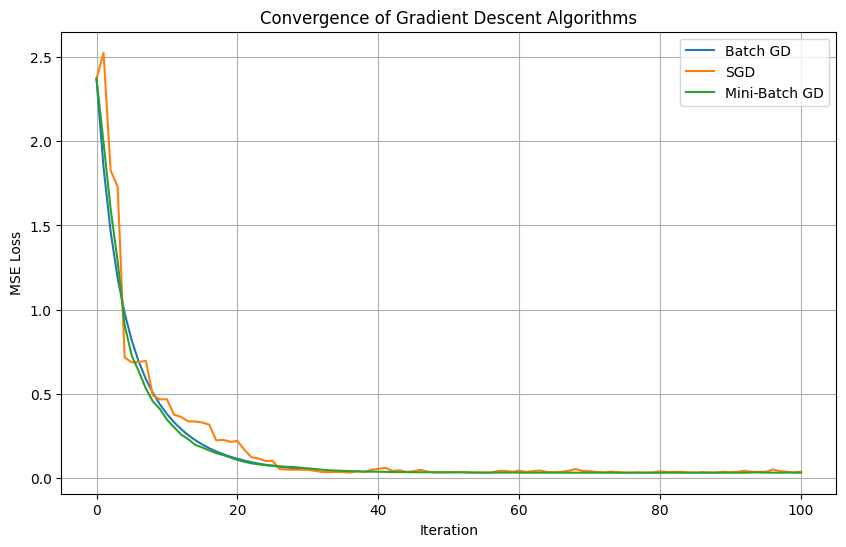

In [12]:
# Convergence Comparison: Batch, Stochastic, and Mini-Batch Gradient Descent
import numpy as np
import matplotlib.pyplot as plt

# Synthetic dataset: y = 2x + 1 + noise
np.random.seed(42)
x = np.linspace(-1, 1, 100)
y_true = 2 * x + 1 + 0.2 * np.random.randn(*x.shape)

# Loss function: MSE for linear regression
def mse_loss(w, b, x, y):
    y_pred = w * x + b
    return np.mean((y - y_pred)**2)

# Batch Gradient Descent
def batch_gd(x, y_true, lr=0.1, n_steps=30):
    w, b = 0.0, 0.0
    losses = [mse_loss(w, b, x, y_true)]
    for step in range(n_steps):
        y_pred = w * x + b
        grad_w = -2 * np.mean((y_true - y_pred) * x)
        grad_b = -2 * np.mean(y_true - y_pred)
        w = w - lr * grad_w
        b = b - lr * grad_b
        losses.append(mse_loss(w, b, x, y_true))
    return losses

# Stochastic Gradient Descent
def sgd(x, y_true, lr=0.1, n_steps=100):
    w, b = 0.0, 0.0
    losses = [mse_loss(w, b, x, y_true)]
    for step in range(n_steps):
        idx = np.random.randint(0, len(x))
        x_i, y_i = x[idx], y_true[idx]
        y_pred = w * x_i + b
        grad_w = -2 * (y_i - y_pred) * x_i
        grad_b = -2 * (y_i - y_pred)
        w = w - lr * grad_w
        b = b - lr * grad_b
        losses.append(mse_loss(w, b, x, y_true))
    return losses

# Mini-Batch Gradient Descent
def minibatch_gd(x, y_true, lr=0.1, n_steps=100, batch_size=16):
    w, b = 0.0, 0.0
    losses = [mse_loss(w, b, x, y_true)]
    for step in range(n_steps):
        idx = np.random.choice(len(x), batch_size, replace=False)
        x_batch = x[idx]
        y_batch = y_true[idx]
        y_pred = w * x_batch + b
        grad_w = -2 * np.mean((y_batch - y_pred) * x_batch)
        grad_b = -2 * np.mean(y_batch - y_pred)
        w = w - lr * grad_w
        b = b - lr * grad_b
        losses.append(mse_loss(w, b, x, y_true))
    return losses

# Run all algorithms
losses_batch = batch_gd(x, y_true)
losses_sgd = sgd(x, y_true)
losses_minibatch = minibatch_gd(x, y_true)

# Plot convergence
plt.figure(figsize=(10, 6))
plt.plot(losses_batch, label='Batch GD')
plt.plot(losses_sgd, label='SGD')
plt.plot(losses_minibatch, label='Mini-Batch GD')
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.title('Convergence of Gradient Descent Algorithms')
plt.legend()
plt.grid(True)
plt.show()

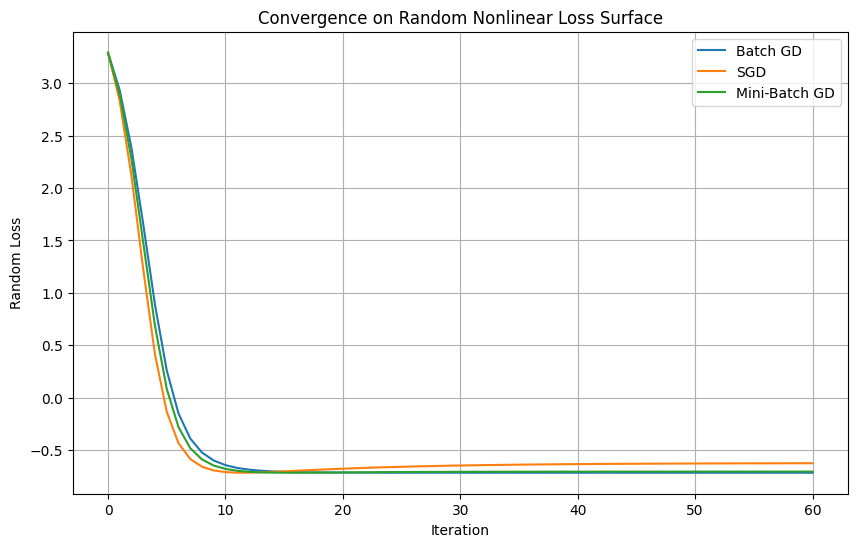

In [13]:
# Convergence Plot for Random Nonlinear Loss Surface
import numpy as np
import matplotlib.pyplot as plt

# Random nonlinear loss function: sum of sinusoids and Gaussians
def random_loss(w):
    np.random.seed(123)
    centers = np.random.uniform(-2, 6, 5)
    amps = np.random.uniform(0.5, 2.0, 5)
    loss = np.sin(w) + 0.5 * np.sin(2*w)
    for c, a in zip(centers, amps):
        loss += a * np.exp(-(w-c)**2)
    return loss

# Numerical gradient
def numerical_grad(f, w):
    eps = 1e-5
    return (f(w + eps) - f(w - eps)) / (2 * eps)

# Batch GD on random loss
def batch_gd_random(f, grad_f, w0, lr, n_steps):
    ws = [w0]
    losses = [f(w0)]
    w = w0
    for _ in range(n_steps):
        g = grad_f(f, w)
        w = w - lr * g
        ws.append(w)
        losses.append(f(w))
    return np.array(ws), np.array(losses)

# SGD on random loss
def sgd_random(f, grad_f, w0, lr, n_steps):
    ws = [w0]
    losses = [f(w0)]
    w = w0
    for _ in range(n_steps):
        noise = np.random.normal(0, 0.5)
        g = grad_f(f, w) + noise
        w = w - lr * g
        ws.append(w)
        losses.append(f(w))
    return np.array(ws), np.array(losses)

# Mini-batch GD (simulated by averaging gradients with noise)
def minibatch_gd_random(f, grad_f, w0, lr, n_steps, batch_size=8):
    ws = [w0]
    losses = [f(w0)]
    w = w0
    for _ in range(n_steps):
        grads = [grad_f(f, w) + np.random.normal(0, 0.2) for _ in range(batch_size)]
        g = np.mean(grads)
        w = w - lr * g
        ws.append(w)
        losses.append(f(w))
    return np.array(ws), np.array(losses)

# Run all algorithms
w0 = 0.0
lr = 0.05
n_steps = 60
ws_batch, losses_batch = batch_gd_random(random_loss, numerical_grad, w0, lr, n_steps)
ws_sgd, losses_sgd = sgd_random(random_loss, numerical_grad, w0, lr, n_steps)
ws_minibatch, losses_minibatch = minibatch_gd_random(random_loss, numerical_grad, w0, lr, n_steps)

# Plot convergence
plt.figure(figsize=(10, 6))
plt.plot(losses_batch, label='Batch GD')
plt.plot(losses_sgd, label='SGD')
plt.plot(losses_minibatch, label='Mini-Batch GD')
plt.xlabel('Iteration')
plt.ylabel('Random Loss')
plt.title('Convergence on Random Nonlinear Loss Surface')
plt.legend()
plt.grid(True)
plt.show()